# Laboratorio 5.3 - Clasificacion Multimodal Multiclase con PyTorch
Estudiante: Valencia Medina Freddy Daniel

Este cuaderno implementa un pipeline multimodal (audio + video) y multiclase en PyTorch siguiendo los cuadernillos:
- Cuadernillo 01: tensores, `device` y uso CPU/GPU
- Cuadernillo 02: `nn.Module`, entrenamiento y metricas
- Cuadernillo 03: `Dataset` y `DataLoader`
- Cuadernillo 04: checkpoints y carga de modelos

Representacion por muestra:
- Audio: 240 features (MFCC + Chroma + Spectral Contrast + ZCR con estadisticas)
- Video: 256 features (HOG facial con pooling temporal mean+std en frames)
- Fusion final: $n=496$ features

Objetivo tecnico: mejorar generalizacion evitando subajuste, sobreajuste y leakage, con un flujo ordenado y reproducible.

## Runbook de ejecucion
1. Cargar dataset y fijar semillas para reproducibilidad.
2. Balancear clases y extraer features de audio.
3. Extraer features de video y fusionar modalidad audio+video.
4. Hacer split por actor (train/val/test), verificar anti-leakage y normalizar.
5. Convertir a tensores y construir `Dataset/DataLoader`.
6. Definir modelo multiclase y funciones de evaluacion.
7. Entrenar con `fit(...)`, scheduler, clipping y early stopping.
8. Revisar curvas y diagnostico de sobreajuste/subajuste.
9. Evaluar mejor checkpoint en test y revisar matriz de confusion.
10. Lanzar Gradio y guardar artefactos finales.

In [2]:
import os
import time
import json
import random
import numpy as np
import pandas as pd
import cv2
import librosa
import seaborn as sns

from matplotlib import pyplot as plt
from IPython.display import Audio, display, Markdown
from skimage.feature import hog
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

%matplotlib inline

SEED = 42
def seed_everything(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(SEED)
print(f'Seeds fijadas en: {SEED}')
print('Librerias importadas correctamente.\n')

start_time = time.time()
dataset_path = '/kaggle/input/datasets/orvile/crema-d-emotional-multimodal-dataset/content/CREMA-D/AudioWAV'
print(f'Directorio base del dataset: {dataset_path}\n')

filepaths = []
labels = []
for filename in sorted(os.listdir(dataset_path)):
    if filename.endswith('.wav'):
        emotion = filename.split('_')[2]
        filepaths.append(os.path.join(dataset_path, filename))
        labels.append(emotion)

df = pd.DataFrame({'Path': filepaths, 'Emotion': labels})
end_time = time.time()

print(f'Total de audios cargados: {len(df)}')
print(f'Clases encontradas: {df["Emotion"].unique()}')
print(f'Tiempo de esta celda: {end_time - start_time:.4f} segundos\n')
display(df.head())

Seeds fijadas en: 42
Librerias importadas correctamente.

Directorio base del dataset: /kaggle/input/datasets/orvile/crema-d-emotional-multimodal-dataset/content/CREMA-D/AudioWAV

Total de audios cargados: 7442
Clases encontradas: ['ANG' 'DIS' 'FEA' 'HAP' 'NEU' 'SAD']
Tiempo de esta celda: 0.1645 segundos



,Path,Emotion
0,/kaggle/input/datasets/orvile/crema-d-emotiona...,ANG
1,/kaggle/input/datasets/orvile/crema-d-emotiona...,DIS
2,/kaggle/input/datasets/orvile/crema-d-emotiona...,FEA
3,/kaggle/input/datasets/orvile/crema-d-emotiona...,HAP
4,/kaggle/input/datasets/orvile/crema-d-emotiona...,NEU


## 2. Balanceo y extraccion de features de audio (Preprocesamiento)

Se balancea por submuestreo usando el tamano de la clase minoritaria para evitar sesgo en entrenamiento.
Luego se extraen 240 features de audio por muestra combinando estadisticas temporales (mean, min, max, std) sobre 60 descriptores base:
- 40 MFCC
- 12 Chroma
- 7 Spectral Contrast
- 1 ZCR

Formalmente:
$$x_{audio}\in\mathbb{R}^{240}$$

Esta parte corresponde al bloque de preparacion de datos previo al entrenamiento PyTorch.

In [3]:
start_time = time.time()

def build_balanced_dataframe(df_in, label_col='Emotion', random_state=42):
    min_count = int(df_in[label_col].value_counts().min())
    df_out = (
        df_in.groupby(label_col, group_keys=False)
        .sample(n=min_count, random_state=random_state)
        .reset_index(drop=True)
    )
    return df_out, min_count

def extract_audio_features_advanced(file_path, duration=2.5, offset=0.5):
    try:
        y, sr = librosa.load(file_path, duration=duration, offset=offset)

        if y is None or len(y) == 0:
            return np.zeros(240, dtype=np.float32)

        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, tuning=0)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        zcr = librosa.feature.zero_crossing_rate(y)

        stacked = np.vstack((mfccs, chroma, contrast, zcr))

        feat_mean = np.mean(stacked, axis=1)
        feat_min = np.min(stacked, axis=1)
        feat_max = np.max(stacked, axis=1)
        feat_std = np.std(stacked, axis=1)

        return np.hstack((feat_mean, feat_min, feat_max, feat_std)).astype(np.float32)
    except Exception:
        return np.zeros(240, dtype=np.float32)

def build_audio_feature_matrix(paths, progress_step=500):
    feats = []
    for i, p in enumerate(paths):
        feats.append(extract_audio_features_advanced(p))
        if (i + 1) % progress_step == 0:
            print(f'Procesados {i + 1} / {len(paths)} audios...')
    return np.array(feats, dtype=np.float32)

print('Iniciando el balanceo del dataset...')
df_balanced, min_count = build_balanced_dataframe(df, label_col='Emotion', random_state=SEED)
print(f'Clase minoritaria: {min_count} audios')
print(f'Tamano del dataset balanceado: {len(df_balanced)}\n')

print('Funcion extract_audio_features_advanced definida correctamente.')
print('Iniciando extraccion de 240 caracteristicas de AUDIO...')
X_full_adv = build_audio_feature_matrix(df_balanced['Path'].tolist(), progress_step=500)
y_full, y_labels = pd.factorize(df_balanced['Emotion'], sort=True)

print('\nGuardando matriz de audio en CSV de respaldo...')
df_features = pd.DataFrame(X_full_adv)
df_features['Target'] = y_full.astype(np.int64)
df_features.to_csv('/kaggle/working/crema_d_audio_adv_balanced.csv', index=False)

end_time = time.time()
print('\nPreprocesamiento de AUDIO completado exitosamente')
print(f'Dimensiones de X_audio: {X_full_adv.shape} -> (m={X_full_adv.shape[0]}, n={X_full_adv.shape[1]})')
print(f'Mapeo de clases: {dict(enumerate(y_labels))}')
print(f'Tiempo total de la celda: {(end_time - start_time)/60:.2f} minutos.')

Iniciando el balanceo del dataset...
Clase minoritaria: 1087 audios
Tamano del dataset balanceado: 6522

Funcion extract_audio_features_advanced definida correctamente.
Iniciando extraccion de 240 caracteristicas de AUDIO...
Procesados 500 / 6522 audios...
Procesados 1000 / 6522 audios...
Procesados 1500 / 6522 audios...
Procesados 2000 / 6522 audios...
Procesados 2500 / 6522 audios...
Procesados 3000 / 6522 audios...
Procesados 3500 / 6522 audios...
Procesados 4000 / 6522 audios...
Procesados 4500 / 6522 audios...
Procesados 5000 / 6522 audios...
Procesados 5500 / 6522 audios...
Procesados 6000 / 6522 audios...
Procesados 6500 / 6522 audios...

Guardando matriz de audio en CSV de respaldo...

Preprocesamiento de AUDIO completado exitosamente
Dimensiones de X_audio: (6522, 240) -> (m=6522, n=240)
Mapeo de clases: {0: 'ANG', 1: 'DIS', 2: 'FEA', 3: 'HAP', 4: 'NEU', 5: 'SAD'}
Tiempo total de la celda: 4.43 minutos.


## 3. Extraccion de features de video y fusion multimodal

Para cada muestra se extraen descriptores HOG en frames distribuidos uniformemente.
En lugar de usar solo promedio temporal, se aplica pooling mean+std para conservar mas dinamica del video:
$$x_{video}=[\mu_{HOG};\sigma_{HOG}]\in\mathbb{R}^{256}$$

Fusion multimodal por concatenacion:
$$x=[x_{audio};x_{video}]\in\mathbb{R}^{496}$$

Esta mejora incrementa capacidad descriptiva sin cambiar la simplicidad del modelo tabular en PyTorch.

In [4]:
print('Iniciando extraccion de propiedades de VIDEO con HOG (modo preciso)...')
start_time = time.time()

def extract_video_features_hog(video_path, n_frames=20):
    if not os.path.exists(video_path):
        return np.zeros(256, dtype=np.float32)

    cap = cv2.VideoCapture(video_path)
    hog_all = []

    try:
        while True:
            ret, frame = cap.read()
            if not ret:
                break

            gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
            resized = cv2.resize(gray, (64, 64), interpolation=cv2.INTER_AREA)
            fd = hog(
                resized,
                orientations=8,
                pixels_per_cell=(16, 16),
                cells_per_block=(1, 1),
            )
            hog_all.append(fd)
    except Exception:
        cap.release()
        return np.zeros(256, dtype=np.float32)

    cap.release()

    if len(hog_all) == 0:
        return np.zeros(256, dtype=np.float32)

    hog_all = np.array(hog_all, dtype=np.float32)

    # Muestreo uniforme sobre todo el video para mantener representatividad temporal.
    n_use = min(n_frames, hog_all.shape[0])
    indices = np.linspace(0, hog_all.shape[0] - 1, n_use, dtype=int)
    sampled = hog_all[indices]

    feat_mean = np.mean(sampled, axis=0)
    feat_std = np.std(sampled, axis=0)
    return np.hstack((feat_mean, feat_std)).astype(np.float32)

video_features_list = []
missing_or_invalid_video = 0

for i, audio_path in enumerate(df_balanced['Path']):
    video_path = audio_path.replace('AudioWAV', 'VideoFlash').replace('.wav', '.flv')
    feat = extract_video_features_hog(video_path, n_frames=20)
    if not np.any(feat):
        missing_or_invalid_video += 1
    video_features_list.append(feat)

    if (i + 1) % 200 == 0:
        print(f'Procesados {i + 1} / {len(df_balanced)} videos...')

X_video_adv = np.array(video_features_list, dtype=np.float32)
print(f'\nDimensiones extraidas del video (HOG mean+std): {X_video_adv.shape}')
print(f'Videos faltantes/corruptos (relleno con ceros): {missing_or_invalid_video}')

# Fusion multimodal: Audio (240) + Video (256)
X_multimodal = np.hstack((X_full_adv, X_video_adv)).astype(np.float32)

end_time = time.time()
print(f'Dimensiones de la matriz MULTIMODAL final (X_multimodal): {X_multimodal.shape} -> n={X_multimodal.shape[1]}')
print(f'Tiempo de procesamiento de video: {(end_time - start_time)/60:.2f} minutos.')

Iniciando extraccion de propiedades de VIDEO con HOG (modo preciso)...
Procesados 200 / 6522 videos...
Procesados 400 / 6522 videos...
Procesados 600 / 6522 videos...
Procesados 800 / 6522 videos...
Procesados 1000 / 6522 videos...
Procesados 1200 / 6522 videos...
Procesados 1400 / 6522 videos...
Procesados 1600 / 6522 videos...
Procesados 1800 / 6522 videos...
Procesados 2000 / 6522 videos...
Procesados 2200 / 6522 videos...
Procesados 2400 / 6522 videos...
Procesados 2600 / 6522 videos...
Procesados 2800 / 6522 videos...
Procesados 3000 / 6522 videos...
Procesados 3200 / 6522 videos...
Procesados 3400 / 6522 videos...
Procesados 3600 / 6522 videos...
Procesados 3800 / 6522 videos...
Procesados 4000 / 6522 videos...
Procesados 4200 / 6522 videos...
Procesados 4400 / 6522 videos...
Procesados 4600 / 6522 videos...
Procesados 4800 / 6522 videos...
Procesados 5000 / 6522 videos...
Procesados 5200 / 6522 videos...
Procesados 5400 / 6522 videos...
Procesados 5600 / 6522 videos...
Procesado

## 4. Split por actor, normalizacion y checkpoint de datos

Se aplica split train/val/test disjunto por actor para medir generalizacion real y evitar leakage por identidad.
Despues se normaliza con estadisticos de train y se guardan artefactos de datos.

Relacion con cuadernillos:
- Cuadernillo 01: normalizacion + tensores
- Cuadernillo 04: guardado para reanudar entrenamiento

In [5]:
def featureNormalize(X_train, X_val, X_test):
    """
    Normaliza con estadisticos de train y aplica a val/test.
    """
    mu = np.mean(X_train, axis=0)
    sigma = np.std(X_train, axis=0)

    # Prevenir división por cero si alguna columna tiene varianza 0
    sigma[sigma == 0] = 1

    X_train_norm = (X_train - mu) / sigma
    X_val_norm = (X_val - mu) / sigma
    X_test_norm = (X_test - mu) / sigma

    return X_train_norm, X_val_norm, X_test_norm, mu, sigma

print("Funcion featureNormalize definida correctamente.")

Funcion featureNormalize definida correctamente.


In [6]:
def extract_actor_id(path):
    filename = os.path.basename(path)
    parts = filename.split('_')
    return parts[0] if len(parts) > 0 else 'UNK'

def build_actor_disjoint_splits(X, y, paths, seed=42, test_size=0.20, val_size_inside_temp=0.125):
    if len(X) != len(y) or len(X) != len(paths):
        raise ValueError('X, y y paths deben tener la misma longitud')

    indices_totales = np.arange(len(X))
    actor_ids = np.array([extract_actor_id(p) for p in paths], dtype=object)
    actores_unicos = np.array(sorted(np.unique(actor_ids)), dtype=object)

    actores_temp, actores_test = train_test_split(
        actores_unicos,
        test_size=test_size,
        random_state=seed,
        shuffle=True,
    )

    actores_train, actores_val = train_test_split(
        actores_temp,
        test_size=val_size_inside_temp,
        random_state=seed,
        shuffle=True,
    )

    mask_train = np.isin(actor_ids, actores_train)
    mask_val = np.isin(actor_ids, actores_val)
    mask_test = np.isin(actor_ids, actores_test)

    idx_train = indices_totales[mask_train]
    idx_val = indices_totales[mask_val]
    idx_test = indices_totales[mask_test]

    return {
        'X_train': X[idx_train],
        'X_val': X[idx_val],
        'X_test': X[idx_test],
        'y_train': y[idx_train],
        'y_val': y[idx_val],
        'y_test': y[idx_test],
        'idx_train': idx_train,
        'idx_val': idx_val,
        'idx_test': idx_test,
        'actor_train': np.array(actores_train, dtype=object),
        'actor_val': np.array(actores_val, dtype=object),
        'actor_test': np.array(actores_test, dtype=object),
        'actor_ids_all': actor_ids,
    }

def check_no_leakage(idx_train, idx_val, idx_test, actor_train, actor_val, actor_test):
    overlap_train_val = len(set(idx_train).intersection(set(idx_val)))
    overlap_train_test = len(set(idx_train).intersection(set(idx_test)))
    overlap_val_test = len(set(idx_val).intersection(set(idx_test)))

    actor_overlap_train_val = len(set(actor_train).intersection(set(actor_val)))
    actor_overlap_train_test = len(set(actor_train).intersection(set(actor_test)))
    actor_overlap_val_test = len(set(actor_val).intersection(set(actor_test)))

    print('\nChequeo de leakage por indices:')
    print(f'Overlap train-val:  {overlap_train_val}')
    print(f'Overlap train-test: {overlap_train_test}')
    print(f'Overlap val-test:   {overlap_val_test}')

    print('\nChequeo de leakage por actor:')
    print(f'Actores compartidos train-val:  {actor_overlap_train_val}')
    print(f'Actores compartidos train-test: {actor_overlap_train_test}')
    print(f'Actores compartidos val-test:   {actor_overlap_val_test}')

    assert overlap_train_val == 0 and overlap_train_test == 0 and overlap_val_test == 0, 'Leakage detectado entre indices de splits'
    assert actor_overlap_train_val == 0 and actor_overlap_train_test == 0 and actor_overlap_val_test == 0, 'Leakage detectado por actor'

paths_all = df_balanced['Path'].tolist()
splits = build_actor_disjoint_splits(X_multimodal, y_full, paths_all, seed=SEED)

X_train = splits['X_train']
X_val = splits['X_val']
X_test = splits['X_test']
y_train = splits['y_train']
y_val = splits['y_val']
y_test = splits['y_test']
idx_train = splits['idx_train']
idx_val = splits['idx_val']
idx_test = splits['idx_test']
actor_train = splits['actor_train']
actor_val = splits['actor_val']
actor_test = splits['actor_test']

print(f'Set Entrenamiento: {X_train.shape[0]} ejemplos')
print(f'Set Validacion:    {X_val.shape[0]} ejemplos')
print(f'Set Prueba:        {X_test.shape[0]} ejemplos')
print(f'Actores unicos: {len(np.unique(splits["actor_ids_all"]))}')
print(f'Actores train/val/test: {len(actor_train)} / {len(actor_val)} / {len(actor_test)}')

check_no_leakage(idx_train, idx_val, idx_test, actor_train, actor_val, actor_test)

# Distribucion por clase
print('\nDistribucion por clase (train/val/test):')
for class_idx, class_name in enumerate(y_labels):
    p_train = (y_train == class_idx).mean() * 100
    p_val = (y_val == class_idx).mean() * 100
    p_test = (y_test == class_idx).mean() * 100
    print(f'{class_name}: train={p_train:.2f}% | val={p_val:.2f}% | test={p_test:.2f}%')

# Normalizacion
X_train_norm, X_val_norm, X_test_norm, mu, sigma = featureNormalize(X_train, X_val, X_test)

print('\nVerificacion de normalizacion:')
print('Train finito:', np.isfinite(X_train_norm).all())
print('Val finito:  ', np.isfinite(X_val_norm).all())
print('Test finito: ', np.isfinite(X_test_norm).all())

# Checkpoint de datos para sesion GPU
np.save('/kaggle/working/X_train_norm.npy', X_train_norm.astype(np.float32))
np.save('/kaggle/working/X_val_norm.npy', X_val_norm.astype(np.float32))
np.save('/kaggle/working/X_test_norm.npy', X_test_norm.astype(np.float32))
np.save('/kaggle/working/y_train.npy', y_train.astype(np.int64))
np.save('/kaggle/working/y_val.npy', y_val.astype(np.int64))
np.save('/kaggle/working/y_test.npy', y_test.astype(np.int64))
np.save('/kaggle/working/mu.npy', mu.astype(np.float32))
np.save('/kaggle/working/sigma.npy', sigma.astype(np.float32))
np.save('/kaggle/working/idx_train.npy', idx_train)
np.save('/kaggle/working/idx_val.npy', idx_val)
np.save('/kaggle/working/idx_test.npy', idx_test)

with open('/kaggle/working/class_names.json', 'w') as f:
    json.dump(list(map(str, y_labels)), f)

with open('/kaggle/working/actors_split.json', 'w') as f:
    json.dump({
        'train': list(map(str, actor_train)),
        'val': list(map(str, actor_val)),
        'test': list(map(str, actor_test)),
    }, f, indent=2)

print('\nCheckpoint de datos guardado en /kaggle/working')

Set Entrenamiento: 4508 ejemplos
Set Validacion:    658 ejemplos
Set Prueba:        1356 ejemplos
Actores unicos: 91
Actores train/val/test: 63 / 9 / 19

Chequeo de leakage por indices:
Overlap train-val:  0
Overlap train-test: 0
Overlap val-test:   0

Chequeo de leakage por actor:
Actores compartidos train-val:  0
Actores compartidos train-test: 0
Actores compartidos val-test:   0

Distribucion por clase (train/val/test):
ANG: train=16.53% | val=16.87% | test=17.04%
DIS: train=16.88% | val=16.57% | test=16.00%
FEA: train=16.61% | val=16.26% | test=17.04%
HAP: train=16.57% | val=16.87% | test=16.89%
NEU: train=16.68% | val=16.41% | test=16.74%
SAD: train=16.73% | val=17.02% | test=16.30%

Verificacion de normalizacion:
Train finito: True
Val finito:   True
Test finito:  True

Checkpoint de datos guardado en /kaggle/working


In [1]:
# Recuperacion opcional del checkpoint de datos (splits + normalizacion)
# Imports para ejecutar esta celda de forma aislada
import os
import json
import numpy as np

DATA_CKPT_DIR = '/kaggle/working'  # Cambia esta ruta segun tu sesion
LOAD_DATA_CHECKPOINT = False       # Pon True para cargar desde archivos guardados

paths = {
    'X_train_norm': os.path.join(DATA_CKPT_DIR, 'X_train_norm.npy'),
    'X_val_norm': os.path.join(DATA_CKPT_DIR, 'X_val_norm.npy'),
    'X_test_norm': os.path.join(DATA_CKPT_DIR, 'X_test_norm.npy'),
    'y_train': os.path.join(DATA_CKPT_DIR, 'y_train.npy'),
    'y_val': os.path.join(DATA_CKPT_DIR, 'y_val.npy'),
    'y_test': os.path.join(DATA_CKPT_DIR, 'y_test.npy'),
    'mu': os.path.join(DATA_CKPT_DIR, 'mu.npy'),
    'sigma': os.path.join(DATA_CKPT_DIR, 'sigma.npy'),
    'idx_val': os.path.join(DATA_CKPT_DIR, 'idx_val.npy'),
    'idx_test': os.path.join(DATA_CKPT_DIR, 'idx_test.npy'),
    'class_names': os.path.join(DATA_CKPT_DIR, 'class_names.json'),
}

if LOAD_DATA_CHECKPOINT:
    missing = [k for k, p in paths.items() if not os.path.exists(p)]
    if missing:
        raise FileNotFoundError(
            f'Faltan archivos del checkpoint en {DATA_CKPT_DIR}: {missing}'
        )

    X_train_norm = np.load(paths['X_train_norm']).astype(np.float32)
    X_val_norm = np.load(paths['X_val_norm']).astype(np.float32)
    X_test_norm = np.load(paths['X_test_norm']).astype(np.float32)

    y_train = np.load(paths['y_train']).astype(np.int64)
    y_val = np.load(paths['y_val']).astype(np.int64)
    y_test = np.load(paths['y_test']).astype(np.int64)

    mu = np.load(paths['mu']).astype(np.float32)
    sigma = np.load(paths['sigma']).astype(np.float32)

    idx_val = np.load(paths['idx_val'])
    idx_test = np.load(paths['idx_test'])

    with open(paths['class_names'], 'r') as f:
        y_labels = np.array(json.load(f), dtype=object)

    print('Checkpoint de datos recuperado correctamente')
    print(f'Ruta base: {DATA_CKPT_DIR}')
    print(f'X_train_norm: {X_train_norm.shape} | X_val_norm: {X_val_norm.shape} | X_test_norm: {X_test_norm.shape}')
else:
    print('LOAD_DATA_CHECKPOINT=False -> se usan datos de la celda anterior.')

LOAD_DATA_CHECKPOINT=False -> se usan datos de la celda anterior.


### 4.1 Conversion a tensores (Cuadernillo 01)
Se convierten los arreglos normalizados a tensores `float32` y etiquetas enteras (`long`) para usar `CrossEntropyLoss` en PyTorch.

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo: {device}')

# Cuadernillo 01: conversion a tensores
X_train_t = torch.from_numpy(X_train_norm).float()
X_val_t = torch.from_numpy(X_val_norm).float()
X_test_t = torch.from_numpy(X_test_norm).float()
y_train_t = torch.from_numpy(y_train).long()
y_val_t = torch.from_numpy(y_val).long()
y_test_t = torch.from_numpy(y_test).long()

print('X_train_t:', X_train_t.shape, X_train_t.dtype)
print('X_val_t:', X_val_t.shape, X_val_t.dtype)
print('y_train_t:', y_train_t.shape, y_train_t.dtype)

Dispositivo: cuda
X_train_t: torch.Size([4508, 496]) torch.float32
X_val_t: torch.Size([658, 496]) torch.float32
y_train_t: torch.Size([4508]) torch.int64


### 4.2 Dataset y DataLoader (Cuadernillo 03)
Se encapsulan tensores en `Dataset` y se crean `DataLoader` para entrenamiento por mini-batches, mejorando rendimiento y estabilidad en GPU/CPU.

In [40]:
# Cuadernillo 03: Dataset y DataLoader
start_time = time.time()

class CremaDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

def build_dataloader(dataset, batch_size, shuffle):
    num_workers = 2
    if num_workers > 0:
        return DataLoader(
            dataset,
            batch_size=batch_size,
            shuffle=shuffle,
            num_workers=num_workers,
            pin_memory=True,
            persistent_workers=True,
        )
    return DataLoader(dataset, batch_size=batch_size, shuffle=shuffle, num_workers=0, pin_memory=True)

print('Clase CremaDataset definida correctamente.')

train_dataset = CremaDataset(X_train_t, y_train_t)
val_dataset = CremaDataset(X_val_t, y_val_t)
test_dataset = CremaDataset(X_test_t, y_test_t)

BATCH_SIZE = 128
train_loader = build_dataloader(train_dataset, BATCH_SIZE, shuffle=True)
val_loader = build_dataloader(val_dataset, BATCH_SIZE, shuffle=False)
test_loader = build_dataloader(test_dataset, BATCH_SIZE, shuffle=False)

xb, yb = next(iter(train_loader))
end_time = time.time()

print('Batch X:', xb.shape, 'Batch y:', yb.shape)
print(f'Batches train: {len(train_loader)} | val: {len(val_loader)} | test: {len(test_loader)}')
print(f'Tiempo de construccion de DataLoaders: {end_time - start_time:.2f} segundos')

Clase CremaDataset definida correctamente.
Batch X: torch.Size([64, 496]) Batch y: torch.Size([64])
Batches train: 71 | val: 11 | test: 22
Tiempo de construccion de DataLoaders: 0.13 segundos


## 5. Red neuronal multiclase en PyTorch (Cuadernillo 02)
Se implementa un modelo `nn.Module` con bloques densos + BatchNorm + Dropout para clasificacion multiclase.
La optimizacion usa `CrossEntropyLoss` con `label_smoothing`, `AdamW`, scheduler y control de gradiente para estabilidad.

In [64]:
num_labels = len(y_labels)
n_features = X_train_t.shape[1]

class GaussianNoise(nn.Module):
    def __init__(self, std=0.03): # Bajamos el ruido, 0.05 era demasiado fuerte
        super().__init__()
        self.std = std

    def forward(self, x):
        if self.training:
            return x + torch.randn_like(x) * self.std
        return x

class EmotionNet(nn.Module):
    def __init__(self, in_features, n_classes):
        super().__init__()
        # Reducimos drásticamente la capacidad (256 -> 64) y subimos los Dropouts
        self.net = nn.Sequential(
            nn.Dropout(0.2), 
            
            nn.Linear(in_features, 256), 
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.5), 

            nn.Linear(256, 64), 
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(64, n_classes), 
        )

    def forward(self, x):
        return self.net(x)

def init_weights(module):
    if isinstance(module, nn.Linear):
        nn.init.kaiming_uniform_(module.weight, nonlinearity='relu')
        if module.bias is not None:
            nn.init.zeros_(module.bias)

print('Clase EmotionNet definida correctamente.')
model = EmotionNet(n_features, num_labels).to(device)
model.apply(init_weights)

criterion = nn.CrossEntropyLoss(label_smoothing=0.1) # Subimos label smoothing a 0.1
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-2) # Maximo weight decay
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
)

print(model)
print('Parametros entrenables:', sum(p.numel() for p in model.parameters()))

Clase EmotionNet definida correctamente.
EmotionNet(
  (net): Sequential(
    (0): Dropout(p=0.2, inplace=False)
    (1): Linear(in_features=496, out_features=256, bias=True)
    (2): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.5, inplace=False)
    (5): Linear(in_features=256, out_features=64, bias=True)
    (6): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.4, inplace=False)
    (9): Linear(in_features=64, out_features=6, bias=True)
  )
)
Parametros entrenables: 144710


### 5.1 Utilidades de evaluacion (Cuadernillo 02)
Esta funcion evalua por loader y retorna `loss`, `accuracy` y `F1-macro`, metricas clave para controlar desbalance entre clases y generalizacion.

In [61]:
def evaluate_loader(model, loader):
    model.eval()
    losses = []
    y_true, y_pred = [], []

    with torch.no_grad():
        for X_batch, y_batch in loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            pred = torch.argmax(logits, dim=1)

            losses.append(loss.item())
            y_true.append(y_batch.cpu().numpy())
            y_pred.append(pred.cpu().numpy())

    y_true = np.concatenate(y_true)
    y_pred = np.concatenate(y_pred)
    acc = accuracy_score(y_true, y_pred)
    f1_macro = f1_score(y_true, y_pred, average='macro')
    return float(np.mean(losses)), acc, f1_macro, y_true, y_pred

print('Funcion evaluate_loader definida correctamente.')

Funcion evaluate_loader definida correctamente.


## 6. Entrenamiento, early stopping y checkpoints (Cuadernillo 02 + 04)
El entrenamiento se encapsula en una funcion `fit(...)` con validacion por epoca.
Se prioriza el mejor checkpoint por `val_f1_macro` (desempate por `val_loss`) y se aplica early stopping para evitar sobreajuste.

En cada epoca se guarda:
- `emotion_last.pt`: ultimo estado
- `emotion_best.pt`: mejor estado segun validacion

### 6.0 Configuracion y recuperacion de checkpoints
Define una carpeta base y nombres de archivos para no depender de una ruta fija de Kaggle. Opcionalmente permite reanudar entrenamiento desde el ultimo checkpoint.

In [65]:
# Configuracion editable de checkpoints
CHECKPOINT_DIR = '/kaggle/working'  # Cambia esta ruta segun tu sesion
BEST_CKPT_NAME = 'emotion_best.pt'  # Cambia nombre si lo deseas
LAST_CKPT_NAME = 'emotion_last.pt'  # Cambia nombre si lo deseas

best_path = os.path.join(CHECKPOINT_DIR, BEST_CKPT_NAME)
last_path = os.path.join(CHECKPOINT_DIR, LAST_CKPT_NAME)

print(f'Ruta checkpoint BEST: {best_path}')
print(f'Ruta checkpoint LAST: {last_path}')

# Opcional: reanudar entrenamiento cargando el ultimo checkpoint
RESUME_FROM_LAST = False

# Si esta en False, no heredara LR bajo ni momentum viejo del optimizador.
RESUME_OPTIMIZER_STATE = False

if RESUME_FROM_LAST:
    if os.path.exists(last_path):
        ckpt_resume = torch.load(last_path, map_location=device)
        model.load_state_dict(ckpt_resume['model_state_dict'])

        if RESUME_OPTIMIZER_STATE and 'optimizer_state_dict' in ckpt_resume:
            optimizer.load_state_dict(ckpt_resume['optimizer_state_dict'])
            print('Se recupero tambien el estado del optimizador.')
        else:
            print('Solo se recupero el modelo (optimizador reiniciara en fit).')

        print(f'Checkpoint recuperado para continuar entrenamiento: {last_path}')
    else:
        print(f'No se encontro checkpoint para reanudar en: {last_path}')

Ruta checkpoint BEST: /kaggle/working/emotion_best.pt
Ruta checkpoint LAST: /kaggle/working/emotion_last.pt


In [66]:
EPOCHS = 100
PATIENCE_ES = 12
MIN_DELTA = 1e-4

# Hiperparametros de optimizacion (se aplican al iniciar cada fit)
BASE_LR = 1e-3
WEIGHT_DECAY = 1e-2 # Fuerte L2 penalty
SCHED_FACTOR = 0.5
SCHED_PATIENCE = 4
MIN_LR = 1e-6

if 'best_path' not in globals() or 'last_path' not in globals():
    CHECKPOINT_DIR = '/kaggle/working'
    BEST_CKPT_NAME = 'emotion_best.pt'
    LAST_CKPT_NAME = 'emotion_last.pt'
    best_path = os.path.join(CHECKPOINT_DIR, BEST_CKPT_NAME)
    last_path = os.path.join(CHECKPOINT_DIR, LAST_CKPT_NAME)

def fit(
    model,
    train_loader,
    val_loader,
    epochs=35,
    patience_es=8,
    min_delta=1e-4,
    best_path='/kaggle/working/emotion_best.pt',
    last_path='/kaggle/working/emotion_last.pt',
    base_lr=1e-3,
    weight_decay=2e-4,
    sched_factor=0.5,
    sched_patience=3,
    min_lr=1e-6,
):
    # Reinicia optimizador/scheduler en cada corrida para evitar heredar LR muy bajo.
    optimizer_local = torch.optim.AdamW(model.parameters(), lr=base_lr, weight_decay=weight_decay)
    scheduler_local = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer_local,
        mode='min',
        factor=sched_factor,
        patience=sched_patience,
        min_lr=min_lr,
    )

    print(f'Inicio fit -> LR inicial: {optimizer_local.param_groups[0]["lr"]:.2e}')

    best_val_loss = float('inf')
    best_val_f1 = -1.0
    epochs_no_improve = 0

    history_train = []
    history_val = []
    history_acc = []
    history_f1 = []
    history_lr = []

    train_start = time.time()

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        model.train()
        train_losses = []

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device, non_blocking=True)
            y_batch = y_batch.to(device, non_blocking=True)

            optimizer_local.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer_local.step()
            train_losses.append(loss.item())

        train_loss = float(np.mean(train_losses))
        val_loss, val_acc, val_f1, _, _ = evaluate_loader(model, val_loader)
        scheduler_local.step(val_loss)

        current_lr = optimizer_local.param_groups[0]['lr']

        history_train.append(train_loss)
        history_val.append(val_loss)
        history_acc.append(val_acc)
        history_f1.append(val_f1)
        history_lr.append(current_lr)

        ckpt = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer_local.state_dict(),
            'train_loss': train_loss,
            'val_loss': val_loss,
            'val_acc': val_acc,
            'val_f1_macro': val_f1,
            'class_names': list(map(str, y_labels)),
        }
        torch.save(ckpt, last_path)

        improved = (val_f1 > best_val_f1 + min_delta) or (
            abs(val_f1 - best_val_f1) <= min_delta and val_loss < best_val_loss - min_delta
        )

        if improved:
            best_val_f1 = val_f1
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save(ckpt, best_path)
        else:
            epochs_no_improve += 1

        epoch_time = time.time() - epoch_start
        print(
            f'Epoch {epoch:02d}/{epochs} | '
            f'train_loss={train_loss:.4f} | val_loss={val_loss:.4f} | '
            f'val_acc={val_acc*100:.2f}% | val_f1_macro={val_f1:.4f} | '
            f'lr={current_lr:.2e} | tiempo={epoch_time:.2f}s'
        )

        if epochs_no_improve >= patience_es:
            print(f'Early stopping en epoch {epoch}. Mejor val_f1_macro={best_val_f1:.4f}')
            break

    total_train_time = time.time() - train_start
    print('\nCheckpoints guardados:')
    print(' - Mejor modelo:', best_path)
    print(' - Ultimo modelo:', last_path)
    print(f'Tiempo total de entrenamiento: {total_train_time/60:.2f} minutos')

    return {
        'history_train': history_train,
        'history_val': history_val,
        'history_acc': history_acc,
        'history_f1': history_f1,
        'history_lr': history_lr,
        'best_val_loss': best_val_loss,
        'best_val_f1': best_val_f1,
        'best_path': best_path,
        'last_path': last_path,
        'train_total_seconds': total_train_time,
    }

fit_out = fit(
    model,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    patience_es=PATIENCE_ES,
    min_delta=MIN_DELTA,
    best_path=best_path,
    last_path=last_path,
    base_lr=BASE_LR,
    weight_decay=WEIGHT_DECAY,
    sched_factor=SCHED_FACTOR,
    sched_patience=SCHED_PATIENCE,
    min_lr=MIN_LR,
 )

history_train = fit_out['history_train']
history_val = fit_out['history_val']
history_acc = fit_out['history_acc']
history_f1 = fit_out['history_f1']
history_lr = fit_out['history_lr']
best_val_loss = fit_out['best_val_loss']
best_val_f1 = fit_out['best_val_f1']

Inicio fit -> LR inicial: 1.00e-03
Epoch 01/100 | train_loss=1.9598 | val_loss=1.5306 | val_acc=39.21% | val_f1_macro=0.3533 | lr=1.00e-03 | tiempo=0.36s
Epoch 02/100 | train_loss=1.6568 | val_loss=1.4625 | val_acc=43.16% | val_f1_macro=0.3885 | lr=1.00e-03 | tiempo=0.34s
Epoch 03/100 | train_loss=1.5544 | val_loss=1.4200 | val_acc=47.42% | val_f1_macro=0.4342 | lr=1.00e-03 | tiempo=0.34s
Epoch 04/100 | train_loss=1.4812 | val_loss=1.3995 | val_acc=49.24% | val_f1_macro=0.4570 | lr=1.00e-03 | tiempo=0.34s
Epoch 05/100 | train_loss=1.4250 | val_loss=1.3785 | val_acc=50.15% | val_f1_macro=0.4638 | lr=1.00e-03 | tiempo=0.35s
Epoch 06/100 | train_loss=1.3828 | val_loss=1.3715 | val_acc=50.76% | val_f1_macro=0.4758 | lr=1.00e-03 | tiempo=0.35s
Epoch 07/100 | train_loss=1.3435 | val_loss=1.3598 | val_acc=51.67% | val_f1_macro=0.4908 | lr=1.00e-03 | tiempo=0.34s
Epoch 08/100 | train_loss=1.3134 | val_loss=1.3707 | val_acc=50.30% | val_f1_macro=0.4783 | lr=1.00e-03 | tiempo=0.33s
Epoch 09/100 

### 6.1 Curvas de aprendizaje
Se visualizan `train_loss`, `val_loss`, `val_acc`, `val_f1_macro` y `learning_rate` para revisar convergencia y estabilidad de entrenamiento.

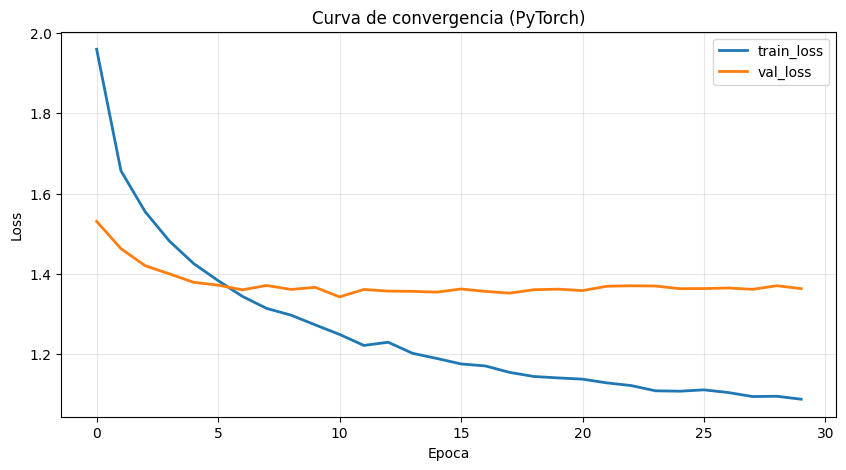

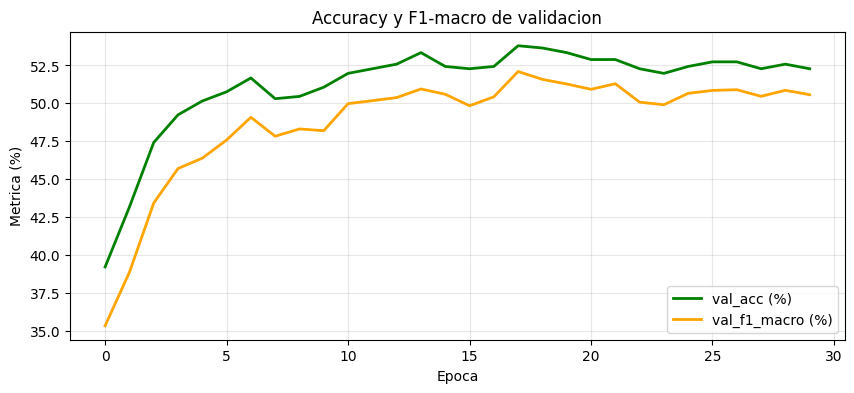

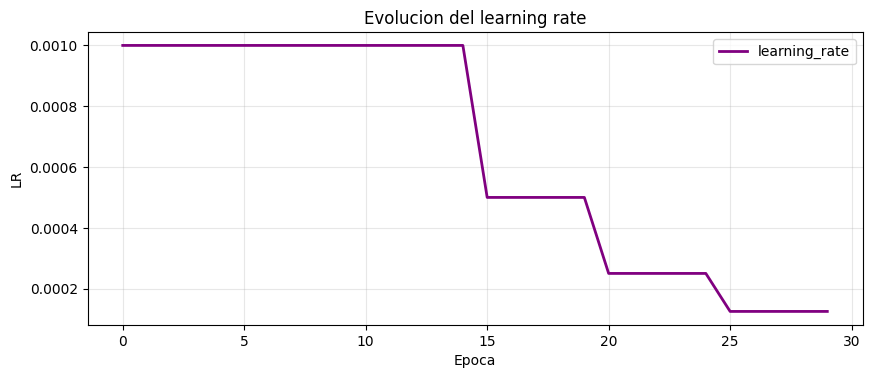

In [67]:
plt.figure(figsize=(10, 5))
plt.plot(history_train, label='train_loss', lw=2)
plt.plot(history_val, label='val_loss', lw=2)
plt.xlabel('Epoca')
plt.ylabel('Loss')
plt.title('Curva de convergencia (PyTorch)')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(np.array(history_acc) * 100, color='green', lw=2, label='val_acc (%)')
plt.plot(np.array(history_f1) * 100, color='orange', lw=2, label='val_f1_macro (%)')
plt.xlabel('Epoca')
plt.ylabel('Metrica (%)')
plt.title('Accuracy y F1-macro de validacion')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

if 'history_lr' in globals() and len(history_lr) > 0:
    plt.figure(figsize=(10, 3.8))
    plt.plot(history_lr, color='purple', lw=2, label='learning_rate')
    plt.xlabel('Epoca')
    plt.ylabel('LR')
    plt.title('Evolucion del learning rate')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

### 6.2 Diagnostico de ajuste (sobreajuste/subajuste)
Con los historiales de entrenamiento y validacion se emite un diagnostico rapido para decidir si regularizar mas, entrenar mas o mantener configuracion.

In [68]:
# Diagnostico rapido de ajuste
if len(history_train) < 2 or len(history_val) < 2:
    print('Historial insuficiente para diagnostico.')
else:
    final_train = float(history_train[-1])
    final_val = float(history_val[-1])
    gap = final_val - final_train

    w = min(5, len(history_train))
    train_improve = float(history_train[-w] - history_train[-1]) if w >= 2 else 0.0
    val_worsen = float(history_val[-1] - history_val[-w]) if w >= 2 else 0.0

    final_f1 = float(history_f1[-1]) if len(history_f1) > 0 else 0.0

    print(f'train_loss final: {final_train:.4f}')
    print(f'val_loss final:   {final_val:.4f}')
    print(f'gap (val-train):  {gap:.4f}')
    print(f'val_f1 final:     {final_f1:.4f}')

    if gap > 0.60:
        print('Diagnostico: SOBREAJUSTE ALTO.')
        print('Accion sugerida: split por actor, subir regularizacion y revisar augmentacion en train.')
    elif gap > 0.25:
        print('Diagnostico: SOBREAJUSTE MODERADO.')
        print('Accion sugerida: aumentar dropout/weight_decay y mantener early stopping.')
    elif gap < 0.03 and final_f1 < 0.60:
        print('Diagnostico: posible SUBAJUSTE.')
        print('Accion sugerida: entrenar mas epocas o ajustar LR/arquitectura.')
    elif train_improve > 0 and val_worsen > 0:
        print('Diagnostico: inicio de SOBREAJUSTE por tendencia reciente.')
        print('Accion sugerida: detener antes o reforzar regularizacion.')
    else:
        print('Diagnostico: comportamiento ESTABLE (sin sobreajuste fuerte).')

train_loss final: 1.0870
val_loss final:   1.3628
gap (val-train):  0.2758
val_f1 final:     0.5057
Diagnostico: SOBREAJUSTE MODERADO.
Accion sugerida: aumentar dropout/weight_decay y mantener early stopping.


## 7. Evaluacion final en test (Cuadernillo 02 + 04)
Se carga el mejor checkpoint seleccionado en validacion y se reportan metricas finales sobre test limpio para estimar generalizacion real.

In [69]:
# Cargar checkpoint configurable y evaluar en test limpio
eval_start = time.time()

CKPT_TO_EVAL = 'best'   # Opciones: 'best' o 'last'
CUSTOM_CKPT_PATH = ''   # Si defines una ruta completa aqui, tiene prioridad

if CUSTOM_CKPT_PATH.strip():
    ckpt_eval_path = CUSTOM_CKPT_PATH.strip()
else:
    ckpt_eval_path = best_path if CKPT_TO_EVAL.lower() == 'best' else last_path

if not os.path.exists(ckpt_eval_path):
    raise FileNotFoundError(f'No se encontro el checkpoint: {ckpt_eval_path}')

ckpt_eval = torch.load(ckpt_eval_path, map_location=device)
model.load_state_dict(ckpt_eval['model_state_dict'])
model.eval()

test_loss, test_acc, test_f1, y_true, y_pred = evaluate_loader(model, test_loader)

eval_time = time.time() - eval_start

print('=' * 60)
print('RESULTADOS FINALES EN TEST (checkpoint seleccionado)')
print('=' * 60)
print(f'Checkpoint cargado desde: {ckpt_eval_path}')
print(f"Epoca del checkpoint: {ckpt_eval['epoch']}")
print(f"Val F1-macro del checkpoint: {ckpt_eval.get('val_f1_macro', float('nan')):.4f}")
print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_acc*100:.2f}%")
print(f"Test F1-macro: {test_f1:.4f}")
print(f"Tiempo de evaluacion en test: {eval_time:.2f} segundos")
print('\nReporte por clase:')
print(classification_report(y_true, y_pred, target_names=list(map(str, y_labels))))

RESULTADOS FINALES EN TEST (checkpoint seleccionado)
Checkpoint cargado desde: /kaggle/working/emotion_best.pt
Epoca del checkpoint: 18
Val F1-macro del checkpoint: 0.5210
Test loss: 1.4458
Test accuracy: 49.85%
Test F1-macro: 0.4890
Tiempo de evaluacion en test: 0.19 segundos

Reporte por clase:
              precision    recall  f1-score   support

         ANG       0.51      0.73      0.60       231
         DIS       0.47      0.38      0.42       217
         FEA       0.41      0.30      0.34       231
         HAP       0.55      0.44      0.49       229
         NEU       0.53      0.59      0.56       227
         SAD       0.49      0.56      0.52       221

    accuracy                           0.50      1356
   macro avg       0.49      0.50      0.49      1356
weighted avg       0.49      0.50      0.49      1356



### 7.1 Inspeccion cualitativa por muestras
Se muestran ejemplos aleatorios de test con audio y etiqueta predicha para auditar errores del modelo mas alla de metricas globales.

## Evaluando Mini-Batch de 5 ejemplos aleatorios

---

### Prueba #1: `1089_TSI_ANG_XX.wav`

Emocion Real: ANG
Prediccion IA: ANG  ✅ ¡CORRECTO!


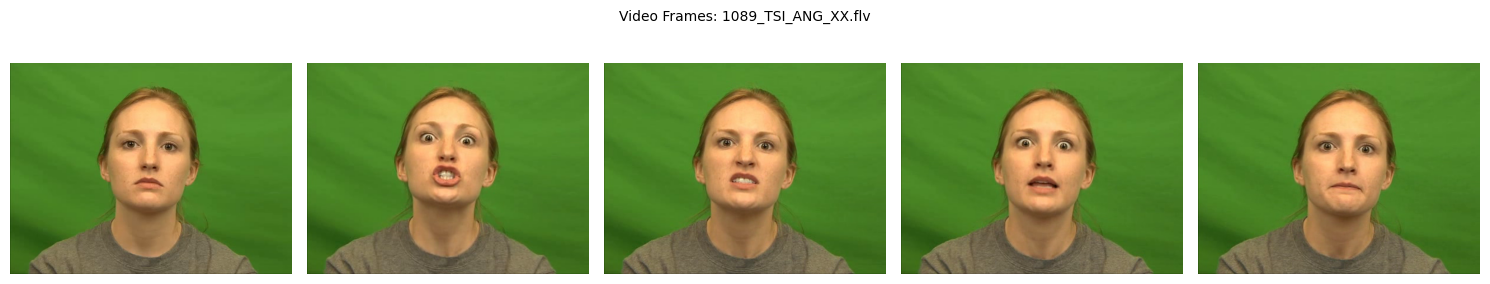

---

### Prueba #2: `1045_ITS_ANG_XX.wav`

Emocion Real: ANG
Prediccion IA: DIS  ❌ INCORRECTO


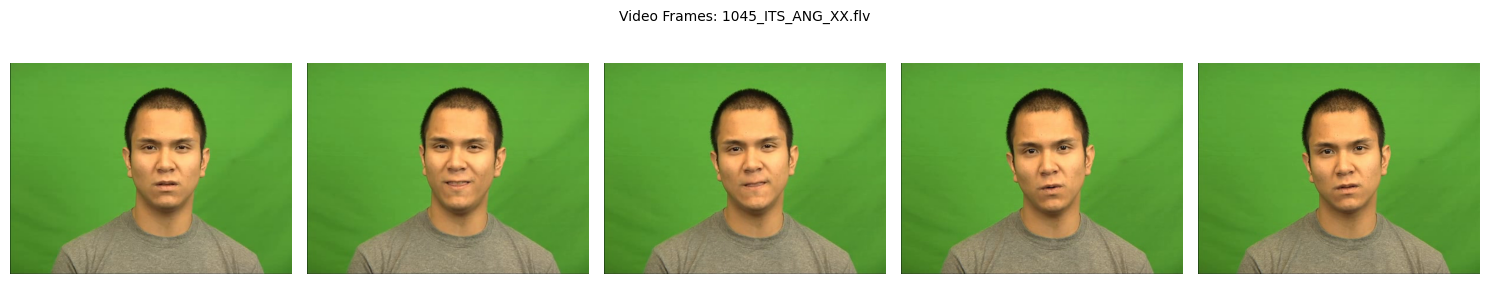

---

### Prueba #3: `1089_IEO_HAP_HI.wav`

Emocion Real: HAP
Prediccion IA: HAP  ✅ ¡CORRECTO!


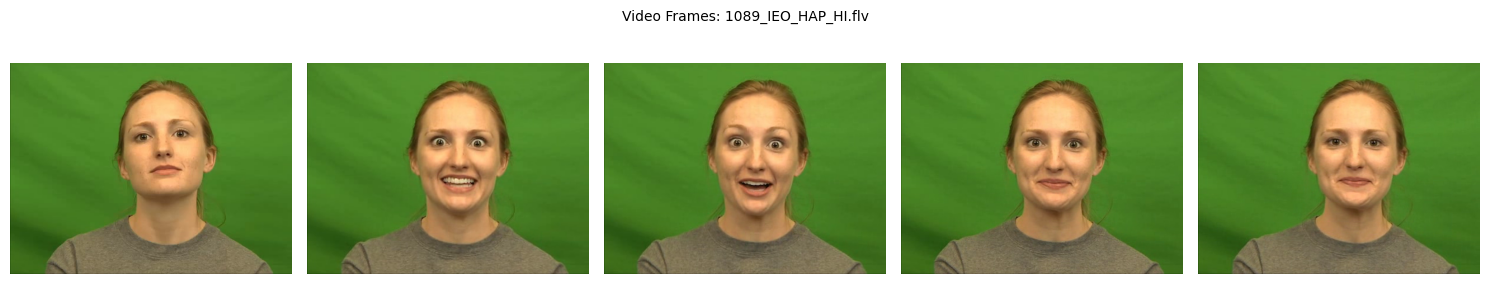

---

### Prueba #4: `1013_MTI_ANG_XX.wav`

Emocion Real: ANG
Prediccion IA: ANG  ✅ ¡CORRECTO!


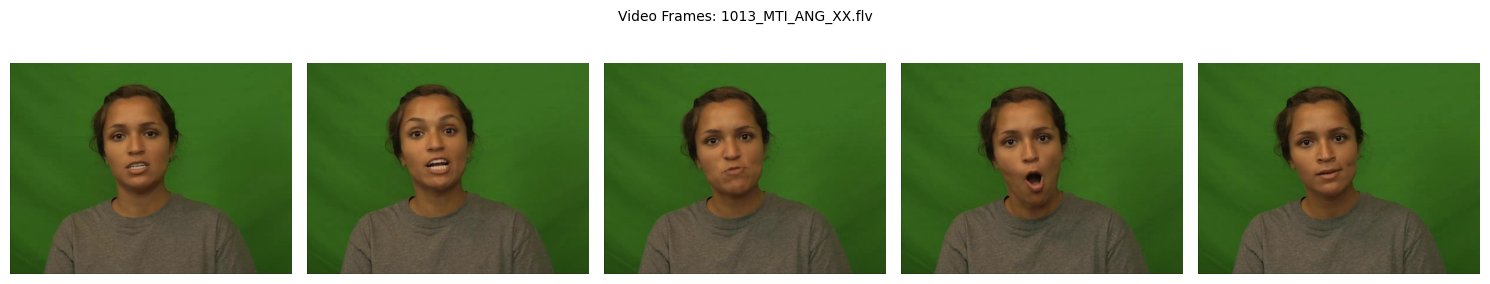

---

### Prueba #5: `1019_IWL_HAP_XX.wav`

Emocion Real: HAP
Prediccion IA: HAP  ✅ ¡CORRECTO!


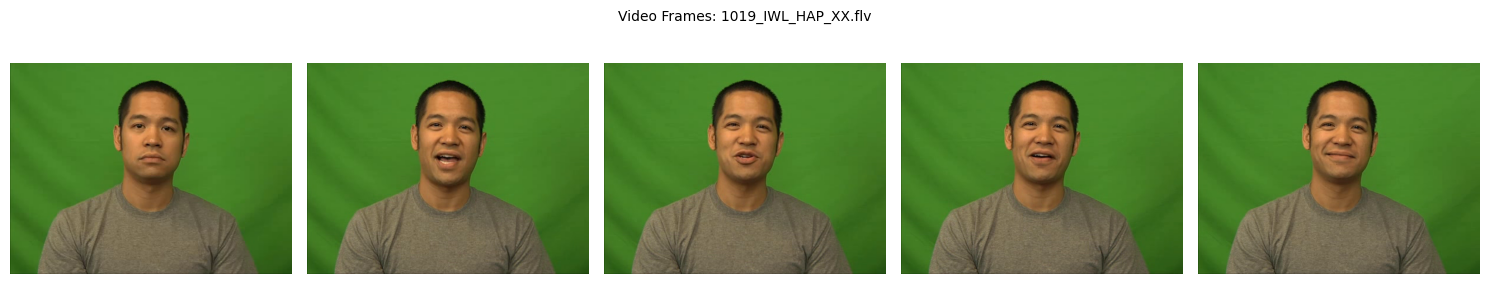

In [72]:
# Mini-batch visual de prueba con PyTorch
num_pruebas = 5
idx_a_clase = {i: str(lbl) for i, lbl in enumerate(y_labels)}

display(Markdown(f"## Evaluando Mini-Batch de {num_pruebas} ejemplos aleatorios"))

for i in range(num_pruebas):
    random_idx = random.randint(0, len(X_test_norm) - 1)
    fila_original = idx_test[random_idx]
    audio_path = df_balanced.iloc[fila_original]['Path']
    video_path = audio_path.replace('AudioWAV', 'VideoFlash').replace('.wav', '.flv')
    etiqueta_real_txt = df_balanced.iloc[fila_original]['Emotion']

    x_sample = torch.from_numpy(X_test_norm[random_idx]).float().unsqueeze(0).to(device)
    with torch.no_grad():
        pred_idx = int(torch.argmax(model(x_sample), dim=1).item())
    etiqueta_predicha_txt = idx_a_clase[pred_idx]
    
    es_correcto = (etiqueta_real_txt == etiqueta_predicha_txt)
    resultado_texto = "✅ ¡CORRECTO!" if es_correcto else "❌ INCORRECTO"

    display(Markdown('---'))
    display(Markdown(f"### Prueba #{i+1}: `{os.path.basename(audio_path)}`"))
    print(f"Emocion Real: {etiqueta_real_txt}")
    print(f"Prediccion IA: {etiqueta_predicha_txt}  {resultado_texto}")
    display(Audio(audio_path))
    
    # Extraer y mostrar 5 frames distribuidos del video original
    if os.path.exists(video_path):
        cap = cv2.VideoCapture(video_path)
        total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
        if total_frames > 0:
            indices = np.linspace(0, total_frames - 1, 5, dtype=int)
            fig, axes = plt.subplots(1, 5, figsize=(15, 3))
            fig.suptitle(f"Video Frames: {os.path.basename(video_path)}", fontsize=10)
            for idx_ax, f_idx in enumerate(indices):
                cap.set(cv2.CAP_PROP_POS_FRAMES, f_idx)
                ret, frame = cap.read()
                if ret:
                    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                    axes[idx_ax].imshow(frame_rgb)
                axes[idx_ax].axis('off')
            plt.tight_layout()
            plt.show()
        cap.release()
    else:
        print(f"Video no encontrado para vista previa: {video_path}")

### 7.2 Matriz de confusion multiclase
Visualiza aciertos y confusiones entre clases para identificar emociones que el modelo mezcla con mayor frecuencia.

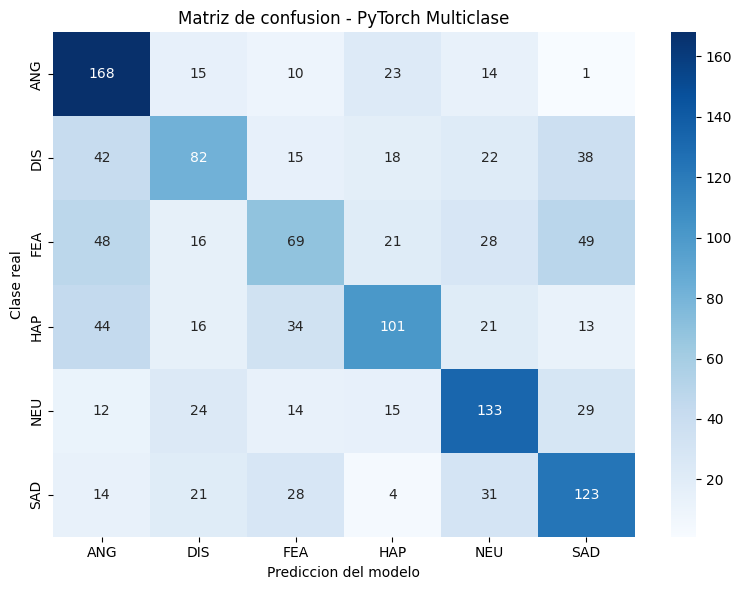

In [73]:
cm = confusion_matrix(y_true, y_pred)
nombres_clases = list(map(str, y_labels))

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=nombres_clases, yticklabels=nombres_clases)
plt.xlabel('Prediccion del modelo')
plt.ylabel('Clase real')
plt.title('Matriz de confusion - PyTorch Multiclase')
plt.tight_layout()
plt.show()

## 8. Despliegue con Gradio
Se prepara una interfaz de inferencia para video de entrada, reutilizando exactamente el mismo pipeline de features y normalizacion del entrenamiento.

In [18]:
!pip install -q gradio

In [19]:
import gradio as gr

CUSTOM_GRADIO_CKPT_PATH = ''  # Opcional: ruta completa a un checkpoint para Gradio
if CUSTOM_GRADIO_CKPT_PATH.strip():
    BEST_MODEL_PATH = CUSTOM_GRADIO_CKPT_PATH.strip()
elif 'best_path' in globals():
    BEST_MODEL_PATH = best_path
else:
    BEST_MODEL_PATH = '/kaggle/working/emotion_best.pt'

if os.path.exists(BEST_MODEL_PATH):
    ckpt_gradio = torch.load(BEST_MODEL_PATH, map_location=device)
    model.load_state_dict(ckpt_gradio['model_state_dict'])
    model.eval()
    print(f'Modelo cargado para Gradio desde: {BEST_MODEL_PATH}')
else:
    model.eval()
    print(f'No se encontro checkpoint en: {BEST_MODEL_PATH}; Gradio usara el modelo actual en memoria.')

def extract_multimodal_features_from_video(video_input_path, n_frames=20):
    # Audio features (240)
    try:
        y, sr = librosa.load(video_input_path, duration=2.5, offset=0.5)
        mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
        chroma = librosa.feature.chroma_stft(y=y, sr=sr, tuning=0)
        contrast = librosa.feature.spectral_contrast(y=y, sr=sr)
        zcr = librosa.feature.zero_crossing_rate(y)
        stacked = np.vstack((mfccs, chroma, contrast, zcr))
        audio_feat = np.hstack([
            np.mean(stacked, axis=1),
            np.min(stacked, axis=1),
            np.max(stacked, axis=1),
            np.std(stacked, axis=1),
        ]).astype(np.float32)
    except Exception:
        audio_feat = np.zeros(240, dtype=np.float32)

    # Video HOG features (256 = mean(128) + std(128))
    v_features_frames = []
    cap = cv2.VideoCapture(video_input_path)
    total = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    if total > 0:
        n_use = min(n_frames, total)
        indices = np.linspace(0, total - 1, n_use, dtype=int)
        for f_idx in indices:
            cap.set(cv2.CAP_PROP_POS_FRAMES, f_idx)
            ret, frame = cap.read()
            if ret:
                gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
                resized = cv2.resize(gray, (64, 64))
                fd = hog(resized, orientations=8, pixels_per_cell=(16, 16), cells_per_block=(1, 1))
                v_features_frames.append(fd)
    cap.release()

    if v_features_frames:
        v_stack = np.array(v_features_frames, dtype=np.float32)
        video_feat = np.hstack((np.mean(v_stack, axis=0), np.std(v_stack, axis=0))).astype(np.float32)
    else:
        video_feat = np.zeros(256, dtype=np.float32)

    x = np.hstack((audio_feat, video_feat)).astype(np.float32)
    return x

print('Funcion extract_multimodal_features_from_video definida correctamente.')

def predecir_emocion(video_input):
    if video_input is None:
        return 'Sube un video primero', 'N/A'

    x = extract_multimodal_features_from_video(video_input)
    sigma_safe = np.where(sigma == 0, 1.0, sigma)
    x_norm = (x - mu) / sigma_safe
    x_tensor = torch.from_numpy(x_norm.astype(np.float32)).unsqueeze(0).to(device)

    with torch.no_grad():
        logits = model(x_tensor)
        probs = torch.softmax(logits, dim=1).cpu().numpy().ravel()
        pred_idx = int(np.argmax(probs))

    pred_label = str(y_labels[pred_idx])
    conf = float(probs[pred_idx]) * 100
    return pred_label, f'{conf:.2f}%'

print('Funcion predecir_emocion definida correctamente.')

demo = gr.Interface(
    fn=predecir_emocion,
    inputs=gr.Video(label='Sube un video (.mp4 o .flv)'),
    outputs=[
        gr.Textbox(label='Emocion predicha'),
        gr.Textbox(label='Confianza'),
    ],
    title='IA Multimodal Multiclase - PyTorch',
    description='Inferencia de emociones usando checkpoint del modelo PyTorch y el mismo pipeline de features del entrenamiento.',
    flagging_mode='never',
)

demo.launch(share=True)

Modelo cargado para Gradio desde: /kaggle/working/emotion_best.pt
Funcion extract_multimodal_features_from_video definida correctamente.
Funcion predecir_emocion definida correctamente.
* Running on local URL:  http://127.0.0.1:7860
* Running on public URL: https://6cebc0000266b3adb1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


## 9. Guardado y verificacion de artefactos (Cuadernillo 04)
Se guardan pesos finales y estadisticos de normalizacion para despliegue reproducible, y luego se verifica la carga del checkpoint.

In [74]:
# Guardado final de artefactos para despliegue
torch.save(model.state_dict(), '/kaggle/working/emotion_model_state_dict.pt')
np.save('/kaggle/working/mu_model.npy', mu.astype(np.float32))
np.save('/kaggle/working/sigma_model.npy', sigma.astype(np.float32))

with open('/kaggle/working/class_names.json', 'w') as f:
    json.dump(list(map(str, y_labels)), f)

metadata = {
    'n_features_total': int(n_features),
    'audio_features': 240,
    'video_features': 256,
    'n_classes': int(num_labels),
    'seed': int(SEED),
}
with open('/kaggle/working/model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('Artefactos guardados:')
print('- emotion_model_state_dict.pt')
print('- emotion_best.pt')
print('- emotion_last.pt')
print('- mu_model.npy')
print('- sigma_model.npy')
print('- class_names.json')
print('- model_metadata.json')

Artefactos guardados:
- emotion_model_state_dict.pt
- emotion_best.pt
- emotion_last.pt
- mu_model.npy
- sigma_model.npy
- class_names.json
- model_metadata.json


In [75]:
# Verificacion de carga de checkpoint final
best_ckpt_path = best_path if 'best_path' in globals() else '/kaggle/working/emotion_best.pt'

if not os.path.exists(best_ckpt_path):
    raise FileNotFoundError(f'No se encontro el checkpoint para verificacion: {best_ckpt_path}')

ckpt = torch.load(best_ckpt_path, map_location=device)
model_check = EmotionNet(n_features, num_labels).to(device)
model_check.load_state_dict(ckpt['model_state_dict'])
model_check.eval()

with open('/kaggle/working/model_metadata.json', 'r') as f:
    meta = json.load(f)

print('Checkpoint cargado correctamente')
print(f'Ruta checkpoint: {best_ckpt_path}')
print(f"Mejor epoca: {ckpt['epoch']}")
print(f"Val loss: {ckpt['val_loss']:.4f}")
print(f"Val acc: {ckpt['val_acc']*100:.2f}%")
print(f"Val F1-macro: {ckpt.get('val_f1_macro', float('nan')):.4f}")
print('Metadata del modelo:', meta)

Checkpoint cargado correctamente
Ruta checkpoint: /kaggle/working/emotion_best.pt
Mejor epoca: 18
Val loss: 1.3516
Val acc: 53.80%
Val F1-macro: 0.5210
Metadata del modelo: {'n_features_total': 496, 'audio_features': 240, 'video_features': 256, 'n_classes': 6, 'seed': 42}
